In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
import math
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

DINIZ EXAMPLE 7.2 - ERROR-FEEDBACK LATTICE RLS EQUALIZER
Channel length                 : 9
Equalizer order                : 25
Equalizer coefficients         : 26
Lambda                         : 0.99
Epsilon                        : 0.1
Equalizer delay L              : 18
Iterations                     : 100
Measured run MSE               : 0.772079
Textbook reference MSE         : 0.305600
Cascade peak sample            : 18
Cascade peak amplitude         : 0.775772


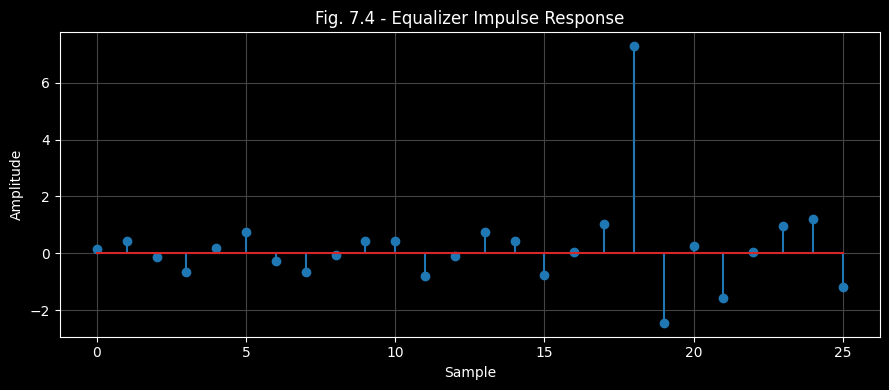

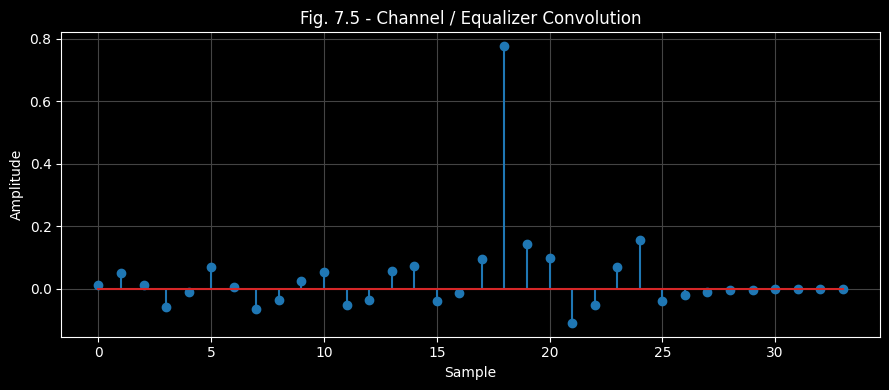

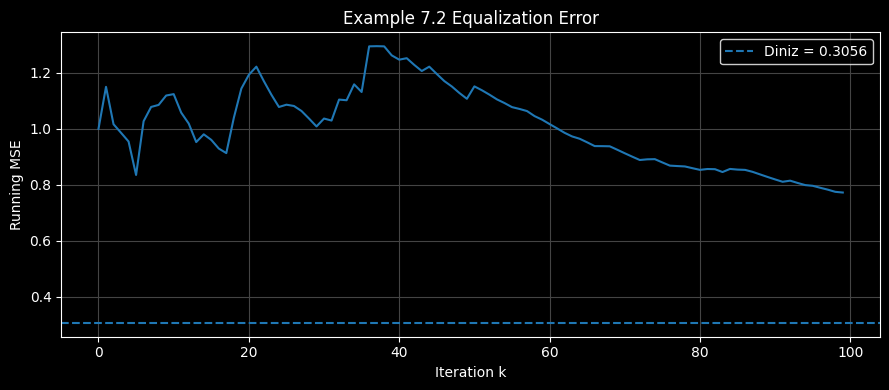

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from adsp import adspdfe


def makeDinizExample72Signals(
  n_samples: int = 100,
  delay: int = 18,
  noise_var: float = 10.0 ** (-2.5),
  seed: int = 1,
):
  """
  Diniz Examples 3.7 / 7.2.

  Channel:
      h(k) = 0.1 * 0.5^k, k = 0,...,8

  Training:
      independent binary samples {-1,+1}

  Channel output:
      u(k) = h(k) * s(k) + n(k)

  Desired equalizer output:
      d(k) = s(k-L)
  """

  rng = np.random.default_rng(seed)

  h = 0.1 * (0.5 ** np.arange(9, dtype=np.float64))

  # Generate prehistory so d(k)=s(k-L) is valid from the first simulated sample.
  prefix = max(delay, len(h) - 1)

  tx = rng.choice([-1.0, 1.0], size=n_samples + prefix)
  channel_full = np.convolve(tx, h, mode="full")

  u_clean = channel_full[prefix:prefix + n_samples]
  noise = rng.normal(0.0, np.sqrt(noise_var), n_samples)
  u = u_clean + noise

  d = tx[prefix - delay:prefix - delay + n_samples]

  return tx, u, d, h


def runDinizExample72(
  n_samples: int = 100,
  seed: int = 1,
):
  """
  Diniz Example 7.2.

  Textbook:
      Error-feedback LRLS
      equalizer order = 25
      lambda = 0.99
      epsilon = 0.1
      L = 18
      coefficients observed after 100 iterations
      reference measured MSE = 0.3056
  """

  delay = 18

  _, u, d, h = makeDinizExample72Signals(
    n_samples=n_samples,
    delay=delay,
    seed=seed,
  )

  eq = adspdfe.ErrorFeedbackLatticeRlsEq(
    n_ff=26,
    n_fb=0,
    lam=0.99,
    epsilon=0.1,
    verify_direct=True,
  )

  y, e = eq(
    u,
    d,
    train=True,
  )

  w_eq = np.real(eq.w).copy()
  cascade = np.convolve(w_eq, h)

  # e is the physical a priori equalizer error.
  mse = float(np.mean(e * e))

  peak_idx = int(np.argmax(np.abs(cascade)))

  print("=" * 72)
  print("DINIZ EXAMPLE 7.2 - ERROR-FEEDBACK LATTICE RLS EQUALIZER")
  print("=" * 72)
  print(f"Channel length                 : {len(h)}")
  print(f"Equalizer order                : {eq.n_ff - 1}")
  print(f"Equalizer coefficients         : {eq.n_ff}")
  print(f"Lambda                         : {eq.lam}")
  print(f"Epsilon                        : {eq.epsilon}")
  print(f"Equalizer delay L              : {delay}")
  print(f"Iterations                     : {n_samples}")
  print(f"Measured run MSE               : {mse:.6f}")
  print(f"Textbook reference MSE         : 0.305600")
  print(f"Cascade peak sample            : {peak_idx}")
  print(f"Cascade peak amplitude         : {cascade[peak_idx]:.6f}")
  print("=" * 72)

  return {
    "equalizer": eq,
    "u": u,
    "d": d,
    "y": y,
    "e": e,
    "h": h,
    "w": w_eq,
    "cascade": cascade,
  }


def plotDinizExample72(result):
  w = result["w"]
  cascade = result["cascade"]
  e = result["e"]

  plt.figure(figsize=(9, 4))
  plt.stem(np.arange(len(w)), w)
  plt.xlabel("Sample")
  plt.ylabel("Amplitude")
  plt.title("Fig. 7.4 - Equalizer Impulse Response")
  plt.grid(True)
  plt.tight_layout()

  plt.figure(figsize=(9, 4))
  plt.stem(np.arange(len(cascade)), cascade)
  plt.xlabel("Sample")
  plt.ylabel("Amplitude")
  plt.title("Fig. 7.5 - Channel / Equalizer Convolution")
  plt.grid(True)
  plt.tight_layout()

  plt.figure(figsize=(9, 4))
  mse_running = np.cumsum(e * e) / np.arange(1, len(e) + 1)
  plt.plot(np.arange(len(e)), mse_running)
  plt.axhline(0.3056, linestyle="--", label="Diniz = 0.3056")
  plt.xlabel("Iteration k")
  plt.ylabel("Running MSE")
  plt.title("Example 7.2 Equalization Error")
  plt.grid(True)
  plt.legend()
  plt.tight_layout()

  plt.show()


if __name__ == "__main__":
  result = runDinizExample72(
    n_samples=100,
    seed=1,
  )

  plotDinizExample72(result)